* [#14](https://github.com/salgo60/ifkdb/issues/14) Boishistoria
* Notebook [14_Boishistoria.ipynb](https://github.com/salgo60/ifkdb/blob/main/Notebook/14_Boishistoria.ipynb)

0.1 fixa bugg [#44](https://github.com/salgo60/ifkdb/issues/44)

In [1]:
from datetime import datetime
start_time  = datetime.now()
print("Last run: ", start_time) 


Last run:  2026-03-29 20:05:03.562654


In [2]:
import requests

url = "https://boishistoria.se/wp/wp-admin/admin-ajax.php"

payload = {
    "action": "REPLACE_WITH_REAL_ACTION",
    # ev. fler parametrar som paged=1, letter=A etc
}

headers = {
    "User-Agent": "Mozilla/5.0",
    "X-Requested-With": "XMLHttpRequest",
}

r = requests.post(url, data=payload, headers=headers)

print("Status:", r.status_code)
print("Length:", len(r.text))

# Spara för inspektion
with open("bois_raw.html", "w", encoding="utf-8") as f:
    f.write(r.text)

Status: 400
Length: 1


In [3]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(r.text, "html.parser")

players = []

for a in soup.find_all("a"):
    name = a.get_text(strip=True)
    if name:
        players.append(name)

print("Antal:", len(players))
players[:20]

Antal: 0


[]

In [4]:
import requests

url = "https://boishistoria.se/wp/wp-admin/admin-ajax.php"

payload = {
    "action": "bois_historia",
    "security": "db140b297c",
    "params[0][name]": "sortera",
    "params[0][value]": "efternamn",
    "params[1][name]": "namn",
    "params[1][value]": "",
    "params[2][name]": "aktiv",
    "params[2][value]": "1915,2026",
    "params[3][name]": "fodd",
    "params[3][value]": "1889,2026",
    "params[4][name]": "vad",
    "params[4][value]": "spelare",
    "params[5][name]": "link",
    "params[5][value]": "visa-data",
}

headers = {
    "User-Agent": "Mozilla/5.0",
    "X-Requested-With": "XMLHttpRequest",
    "Referer": "https://boishistoria.se/spelare/"
}

r = requests.post(url, data=payload, headers=headers)

print("Status:", r.status_code)
print("Length:", len(r.text))
print(r.text[:1000])

Status: 200
Length: 100971
<!-- Sökning efter spelare (incs/sok_spelare.php)(1) -->
<!-- Sökning efter spelare (incs/sok_spelare.php)(2) -->
<h5 class="mb-0">A</h5><a href="https://boishistoria.se/visa-data/?what=spelare&id=569&link=visa-data">Abo-Shark, Mohamed</a><br><a href="https://boishistoria.se/visa-data/?what=spelare&id=549&link=visa-data">Adelstam, Mattias</a><br><a href="https://boishistoria.se/visa-data/?what=spelare&id=347&link=visa-data">Afzelius, Jan</a><br><a href="https://boishistoria.se/visa-data/?what=spelare&id=6&link=visa-data">Aganovic, Admir</a><br><a href="https://boishistoria.se/visa-data/?what=spelare&id=211&link=visa-data">Aguiar, Fernando</a><br><a href="https://boishistoria.se/visa-data/?what=spelare&id=221&link=visa-data">Ahl, Fredrik</a><br><a href="https://boishistoria.se/visa-data/?what=spelare&id=182&link=visa-data">Ahmetovic, Enis</a><br><a href="https://boishistoria.se/visa-data/?what=spelare&id=734&link=visa-data">Ahnelöv, Sten</a><br><a href="https:

In [5]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(r.text, "html.parser")

players = []

# Justera selektor efter hur HTML faktiskt ser ut
for a in soup.find_all("a"):
    name = a.get_text(strip=True)
    if name:
        players.append(name)

print("Antal spelare:", len(players))
players[:20]

Antal spelare: 967


['Abo-Shark, Mohamed',
 'Adelstam, Mattias',
 'Afzelius, Jan',
 'Aganovic, Admir',
 'Aguiar, Fernando',
 'Ahl, Fredrik',
 'Ahmetovic, Enis',
 'Ahnelöv, Sten',
 'Ajakpoloho, Christian',
 'Akpoveta, Ojevwe',
 'al Kurdi, Raslan',
 'Al-Karkhi, Ramy',
 'Albrechtsson, Gunnar',
 'Alcalde Tieles, Donato "Tati"',
 'Algerbo, Lars-Göran',
 'Alin, Kevin',
 'Alm, Lars',
 'Alm, Rasmus',
 'Alm, Simon',
 'Almadjed, Sumar']

In [6]:
len(players), len(set(players))

(967, 960)

In [7]:
from bs4 import BeautifulSoup
from urllib.parse import urljoin, parse_qs, urlparse

base = "https://boishistoria.se"

soup = BeautifulSoup(r.text, "html.parser")

players = []

for a in soup.find_all("a", href=True):
    href = a["href"]
    if "what=spelare" in href:
        name = a.get_text(strip=True)
        
        # extrahera id
        parsed = urlparse(href)
        qs = parse_qs(parsed.query)
        player_id = qs.get("id", [None])[0]

        players.append({
            "name": name,
            "id": player_id,
            "url": urljoin(base, href)
        })

len(players), players[:5]

(967,
 [{'name': 'Abo-Shark, Mohamed',
   'id': '569',
   'url': 'https://boishistoria.se/visa-data/?what=spelare&id=569&link=visa-data'},
  {'name': 'Adelstam, Mattias',
   'id': '549',
   'url': 'https://boishistoria.se/visa-data/?what=spelare&id=549&link=visa-data'},
  {'name': 'Afzelius, Jan',
   'id': '347',
   'url': 'https://boishistoria.se/visa-data/?what=spelare&id=347&link=visa-data'},
  {'name': 'Aganovic, Admir',
   'id': '6',
   'url': 'https://boishistoria.se/visa-data/?what=spelare&id=6&link=visa-data'},
  {'name': 'Aguiar, Fernando',
   'id': '211',
   'url': 'https://boishistoria.se/visa-data/?what=spelare&id=211&link=visa-data'}])

In [8]:
resultbug = [item for item in players if item["id"] == "620"]

In [9]:
resultbug

[{'name': 'Svensson, Ove "Saltö"',
  'id': '620',
  'url': 'https://boishistoria.se/visa-data/?what=spelare&id=620&link=visa-data'}]

In [10]:
import requests
from bs4 import BeautifulSoup

def fetch_birthdate(player):
    r = requests.get(player["url"])
    soup = BeautifulSoup(r.text, "html.parser")
    
    strong = soup.find("strong", string="Född:")
    if strong:
        td = strong.find_parent("td").find_next_sibling("td")
        if td:
            return td.get_text(strip=True)
    
    return None

# testa första spelaren
test = players[0]
birth = fetch_birthdate(test)
print(test["name"], birth)

Abo-Shark, Mohamed 1994-01-29


In [11]:
import json
import os
import time

CACHE_FILE = "bois_birth_cache.json"
rerunBOIS = False   # <-- sätt True om du vill tvinga omkörning

if os.path.exists(CACHE_FILE) and not rerunBOIS:
    with open(CACHE_FILE, "r", encoding="utf-8") as f:
        birth_cache = json.load(f)
    print("Cache laddad:", len(birth_cache), "poster")
else:
    birth_cache = {}
    print("Ny cache startad")

Cache laddad: 967 poster


In [12]:
for i, p in enumerate(players):
    
    pid = p["id"]
    
    # Om finns i cache → använd den
    if pid in birth_cache and not rerunBOIS:
        p["birth"] = birth_cache[pid]
        continue
    
    try:
        birth = fetch_birthdate(p)
        p["birth"] = birth
        birth_cache[pid] = birth
        
        time.sleep(0.3)
        
    except Exception:
        p["birth"] = None
        birth_cache[pid] = None
    
    # Spara cache var 50:e spelare
    if i % 50 == 0:
        with open(CACHE_FILE, "w", encoding="utf-8") as f:
            json.dump(birth_cache, f, ensure_ascii=False, indent=2)
        print("Processed", i)

# Slutsparning
with open(CACHE_FILE, "w", encoding="utf-8") as f:
    json.dump(birth_cache, f, ensure_ascii=False, indent=2)

print("Klar. Totalt spelare:", len(players))

Klar. Totalt spelare: 967


In [56]:
players[1:10]

[{'name': 'Adelstam, Mattias',
  'id': '549',
  'url': 'https://boishistoria.se/visa-data/?what=spelare&id=549&link=visa-data',
  'birth': '1982-03-07'},
 {'name': 'Afzelius, Jan',
  'id': '347',
  'url': 'https://boishistoria.se/visa-data/?what=spelare&id=347&link=visa-data',
  'birth': '1952-03-02'},
 {'name': 'Aganovic, Admir',
  'id': '6',
  'url': 'https://boishistoria.se/visa-data/?what=spelare&id=6&link=visa-data',
  'birth': '1986-08-25'},
 {'name': 'Aguiar, Fernando',
  'id': '211',
  'url': 'https://boishistoria.se/visa-data/?what=spelare&id=211&link=visa-data',
  'birth': '1972-03-18'},
 {'name': 'Ahl, Fredrik',
  'id': '221',
  'url': 'https://boishistoria.se/visa-data/?what=spelare&id=221&link=visa-data',
  'birth': '1987-06-08'},
 {'name': 'Ahmetovic, Enis',
  'id': '182',
  'url': 'https://boishistoria.se/visa-data/?what=spelare&id=182&link=visa-data',
  'birth': '1992-01-26'},
 {'name': 'Ahnelöv, Sten',
  'id': '734',
  'url': 'https://boishistoria.se/visa-data/?what=sp

In [14]:
resultbug2 = [item for item in players if item["id"] == "620"] 
resultbug2

[{'name': 'Svensson, Ove "Saltö"',
  'id': '620',
  'url': 'https://boishistoria.se/visa-data/?what=spelare&id=620&link=visa-data',
  'birth': '1937-11-10'}]

In [15]:
# Hämta WD
from SPARQLWrapper import SPARQLWrapper, JSON

sparql = SPARQLWrapper("https://query.wikidata.org/sparql")

query = """
SELECT ?item ?itemLabel ?birth ?death WHERE {
  ?item wdt:P54 wd:Q863273 .
  OPTIONAL { ?item wdt:P569 ?birth . }
  OPTIONAL { ?item wdt:P570 ?death . }
  SERVICE wikibase:label {
    bd:serviceParam wikibase:language "sv,en,mul" .
  }
}
"""

sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

wd_players = []

for r in results["results"]["bindings"]:
    wd_players.append({
        "qid": r["item"]["value"].split("/")[-1],
        "name": r["itemLabel"]["value"],
        "birth": r.get("birth", {}).get("value"),
        "death": r.get("death", {}).get("value")
    })

len(wd_players), wd_players[:5]

(284,
 [{'qid': 'Q128845',
   'name': 'Lee Baxter',
   'birth': '1976-06-17T00:00:00Z',
   'death': None},
  {'qid': 'Q151373',
   'name': 'Babis Stefanidis',
   'birth': '1981-03-08T00:00:00Z',
   'death': None},
  {'qid': 'Q176721',
   'name': 'André Schei Lindbæk',
   'birth': '1977-11-01T00:00:00Z',
   'death': None},
  {'qid': 'Q177434',
   'name': 'Jörgen Pettersson',
   'birth': '1975-09-29T00:00:00Z',
   'death': None},
  {'qid': 'Q195874',
   'name': 'Joakim Nilsson',
   'birth': '1966-03-31T00:00:00Z',
   'death': None}])

In [16]:
#normaliser   
import re

def normalize_bois(name):
    name = re.sub(r'"[^"]+"', '', name)
    name = re.sub(r'\([^)]*\)', '', name)
    name = re.sub(r'\b\d{2,4}\b$', '', name)
    name = name.strip()
    
    if "," in name:
        last, first = name.split(",", 1)
        name = first.strip() + " " + last.strip()
    
    return " ".join(name.split())

bois_clean = []
for p in players:
    bois_clean.append({
        "name": normalize_bois(p["name"]),
        "birth": p.get("birth")
    })

len(bois_clean)

967

In [17]:
bois_clean[0:10]

[{'name': 'Mohamed Abo-Shark', 'birth': '1994-01-29'},
 {'name': 'Mattias Adelstam', 'birth': '1982-03-07'},
 {'name': 'Jan Afzelius', 'birth': '1952-03-02'},
 {'name': 'Admir Aganovic', 'birth': '1986-08-25'},
 {'name': 'Fernando Aguiar', 'birth': '1972-03-18'},
 {'name': 'Fredrik Ahl', 'birth': '1987-06-08'},
 {'name': 'Enis Ahmetovic', 'birth': '1992-01-26'},
 {'name': 'Sten Ahnelöv', 'birth': '1926-01-18'},
 {'name': 'Christian Ajakpoloho', 'birth': '1993-01-01'},
 {'name': 'Ojevwe Akpoveta', 'birth': '1993-07-15'}]

In [18]:
resultbug3 = [item for item in bois_clean if "Svensson, Ove" in item["name"]] 
resultbug3

[]

In [19]:
# matcha   
wd_index = {}
for w in wd_players:
    key = (w["name"], w["birth"])
    wd_index[key] = w["qid"]

matches = []
missing = []

for p in bois_clean:
    key = (p["name"], p["birth"])
    if key in wd_index:
        matches.append(p)
    else:
        missing.append(p)

len(matches), len(missing)

(0, 967)

In [20]:
# normalisera birth    
from datetime import datetime

def normalize_wd_birth(b):
    if not b:
        return None
    return b[:10]   # snabbaste och säkraste

for w in wd_players:
    w["birth"] = normalize_wd_birth(w["birth"]) 

wd_players[:5]

[{'qid': 'Q128845',
  'name': 'Lee Baxter',
  'birth': '1976-06-17',
  'death': None},
 {'qid': 'Q151373',
  'name': 'Babis Stefanidis',
  'birth': '1981-03-08',
  'death': None},
 {'qid': 'Q176721',
  'name': 'André Schei Lindbæk',
  'birth': '1977-11-01',
  'death': None},
 {'qid': 'Q177434',
  'name': 'Jörgen Pettersson',
  'birth': '1975-09-29',
  'death': None},
 {'qid': 'Q195874',
  'name': 'Joakim Nilsson',
  'birth': '1966-03-31',
  'death': None}]

In [21]:
wd_index = {
    (w["name"], w["birth"]): w["qid"]
    for w in wd_players
}

matches = []
missing = []

for p in bois_clean:
    key = (p["name"], p["birth"])
    if key in wd_index:
        matches.append(p)
    else:
        missing.append(p)

len(matches), len(missing)

(215, 752)

In [57]:
# bois_clean

In [23]:
resultbug4 = [item for item in bois_clean if "Svensson" in item["name"]] 
resultbug4

[{'name': 'Adam Svensson', 'birth': '1991-04-13'},
 {'name': 'Bo Svensson', 'birth': '1944-09-07'},
 {'name': 'Gert-Inge Svensson', 'birth': '1945-11-07'},
 {'name': 'John Svensson', 'birth': '1900-03-10'},
 {'name': 'Mats Svensson', 'birth': '1971-11-22'},
 {'name': 'Niklas Svensson', 'birth': '1970-04-14'},
 {'name': 'Nils Svensson', 'birth': '1902-12-05'},
 {'name': 'Ove Svensson', 'birth': '1927-12-18'},
 {'name': 'Ove Svensson', 'birth': '1937-11-10'},
 {'name': 'Ragnar Svensson', 'birth': '1902-01-11'},
 {'name': 'Rolf Svensson', 'birth': None},
 {'name': 'Thomas Svensson', 'birth': '1971-03-04'},
 {'name': 'Tore Svensson', 'birth': '1928-05-21'},
 {'name': 'Viktor Svensson', 'birth': '1990-03-06'}]

In [24]:
resultbug5 = [item for item in bois_clean if "John Nilsson" in item["name"]] 
resultbug5

[{'name': 'John Nilsson', 'birth': '1909-09-04'}]

In [25]:
# namn matcha   
wd_name_index = {w["name"]: w for w in wd_players}

name_only_matches = []
still_missing = []

for p in bois_clean:
    if p["name"] in wd_name_index:
        name_only_matches.append(p)
    else:
        still_missing.append(p)

len(name_only_matches), len(still_missing)

(240, 727)

In [26]:
wd_without_birth = [w for w in wd_players if not w["birth"]]
len(wd_without_birth)

1

In [27]:
from rapidfuzz import process, fuzz

fuzzy_strict = []
fuzzy_flagged = []

wd_names = [w["name"] for w in wd_players]

for p in still_missing:
    match, score, _ = process.extractOne(
        p["name"],
        wd_names,
        scorer=fuzz.token_sort_ratio
    )
    
    if score >= 92:
        wd_obj = next(w for w in wd_players if w["name"] == match)
        
        if wd_obj["birth"] and p["birth"]:
            if wd_obj["birth"] == p["birth"]:
                fuzzy_strict.append(p)
        else:
            fuzzy_flagged.append(p)

len(fuzzy_strict), len(fuzzy_flagged)

(16, 0)

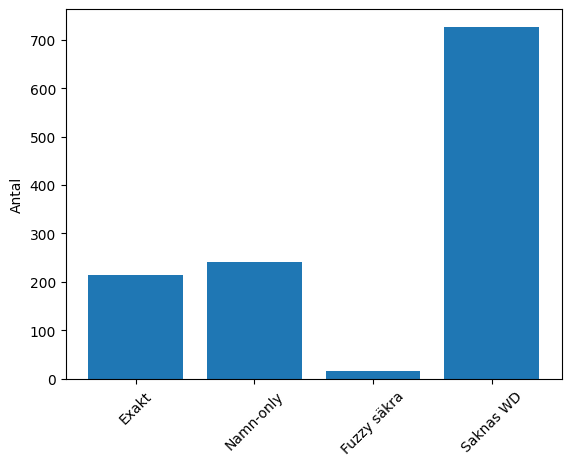

In [28]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(
    ["Exakt", "Namn-only", "Fuzzy säkra", "Saknas WD"],
    [
        len(matches),
        len(name_only_matches),
        len(fuzzy_strict),
        len(still_missing)
    ]
)
plt.xticks(rotation=45)
plt.ylabel("Antal")
plt.show()

In [29]:
import requests
import time

S = requests.Session()
S.headers.update({
    "User-Agent": "BoIS-POC/1.0 (https://github.com/yourrepo; contact: salgo60@msn.com)"
})

URL = "https://sv.wikipedia.org/w/api.php"

def get_category_members():
    members = []
    
    params = {
        "action": "query",
        "list": "categorymembers",
        "cmtitle": "Kategori:Fotbollsspelare i Landskrona BoIS",
        "cmlimit": "500",
        "format": "json",
        "formatversion": "2"
    }

    while True:
        r = S.get(URL, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()
        
        members.extend(data["query"]["categorymembers"])
        
        if "continue" in data:
            params.update(data["continue"])
            time.sleep(0.5)
        else:
            break

    return members

wiki_members = get_category_members()
wiki_titles = [m["title"] for m in wiki_members]

len(wiki_titles), wiki_titles[:10]

(216,
 ['Mattias Adelstam',
  'Admir Aganović',
  'Fernando Aguiar',
  'Enis Ahmetovic',
  'Lars Alm',
  'Rasmus Alm',
  'Knut Almqvist (fotbollsspelare)',
  'Stefan Alvén',
  'Kevin Amuneke',
  'John Anderberg'])

In [30]:
resultbug6 = [item for item in bois_clean if "Svensson, Ove" in item["name"]] 
resultbug6 
resultbug7 = [item for item in bois_clean if "John Nilsson" in item["name"]] 
resultbug7

[{'name': 'John Nilsson', 'birth': '1909-09-04'}]

In [31]:
def get_qids(titles):
    qids = {}
    
    for title in titles:
        params = {
            "action": "query",
            "prop": "pageprops",
            "titles": title,
            "format": "json",
            "formatversion": "2"
        }
        
        r = S.get(URL, params=params)
        data = r.json()
        
        pages = data["query"]["pages"]
        if pages and "pageprops" in pages[0]:
            qid = pages[0]["pageprops"].get("wikibase_item")
            if qid:
                qids[title] = qid
        
        time.sleep(0.2)
    
    return qids

wiki_qids = get_qids(wiki_titles)
len(wiki_qids)

215

In [32]:
def normalize_wiki(name):
    return " ".join(name.strip().split())

wiki_clean = [normalize_wiki(t) for t in wiki_titles]
len(wiki_clean)

216

In [33]:
# Wikipedia vs Wikidata
wd_names_set = set([w["name"] for w in wd_players])
wiki_set = set(wiki_clean)

wiki_not_in_wd = wiki_set - wd_names_set
wd_not_in_wiki = wd_names_set - wiki_set

len(wiki_not_in_wd), len(wd_not_in_wiki)

(34, 99)

In [34]:
# B) BoIS vs Wikipedia   
# Detta visar hur elitfokuserad Wikipedia är.
bois_set = set([p["name"] for p in bois_clean])

bois_in_wiki = bois_set & wiki_set
bois_not_in_wiki = bois_set - wiki_set

len(bois_in_wiki), len(bois_not_in_wiki)

(156, 775)

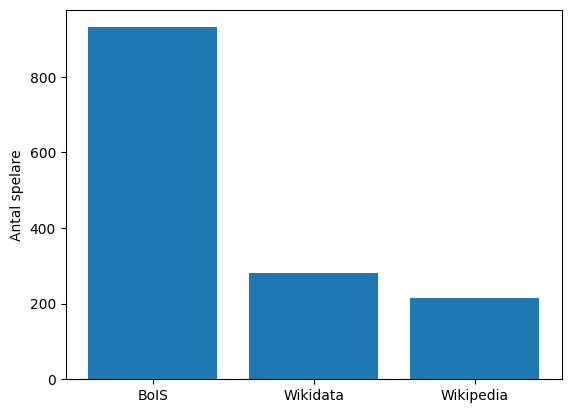

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(
    ["BoIS", "Wikidata", "Wikipedia"],
    [len(bois_set), len(wd_names_set), len(wiki_set)]
)
plt.ylabel("Antal spelare")
plt.show()

In [36]:
# Fuzzy match mot Wikipedia  
from rapidfuzz import process, fuzz

wiki_names = list(wiki_set)

wiki_fuzzy = []
wiki_still_missing = []

for name in bois_not_in_wiki:
    match, score, _ = process.extractOne(
        name,
        wiki_names,
        scorer=fuzz.token_sort_ratio
    )
    
    if score >= 93:
        wiki_fuzzy.append((name, match, score))
    else:
        wiki_still_missing.append(name)

len(wiki_fuzzy), len(wiki_still_missing)

(6, 769)

In [37]:
wiki_fuzzy

[('Mirza Selimovic', 'Mirza Selimović', 93.33333333333333),
 ('Viktor Karlsson', 'Victor Karlsson', 93.33333333333333),
 ('John Jönsson', 'Jon Jönsson', 95.65217391304348),
 ('Bahrudin Atajic', 'Bahrudin Atajić', 93.33333333333333),
 ('Morten Nordbeck', 'Mårten Nordbeck', 93.33333333333333),
 ('Johnny Kongsbög', 'Johnny Kongsbøg', 93.33333333333333)]

In [38]:
wiki_clean[:5]

['Mattias Adelstam',
 'Admir Aganović',
 'Fernando Aguiar',
 'Enis Ahmetovic',
 'Lars Alm']

In [39]:
bois_set = set([p["name"] for p in bois_clean])
wiki_set = set(wiki_clean)

wiki_exact = bois_set & wiki_set
len(wiki_exact)

156

In [40]:
print("Exakt:", len(wiki_exact))
print("Fuzzy:", len(wiki_fuzzy))
print("Saknas:", len(wiki_still_missing))

Exakt: 156
Fuzzy: 6
Saknas: 769


In [41]:
bois_not_in_wiki = bois_set - wiki_set
wiki_not_in_bois = wiki_set - bois_set

len(bois_not_in_wiki), len(wiki_not_in_bois)

(775, 60)

In [42]:
from rapidfuzz import process, fuzz

wiki_names = list(wiki_set)

wiki_fuzzy = []
wiki_still_missing = []

for name in bois_not_in_wiki:
    match, score, _ = process.extractOne(
        name,
        wiki_names,
        scorer=fuzz.token_sort_ratio
    )
    
    if score >= 93:
        wiki_fuzzy.append((name, match, score))
    else:
        wiki_still_missing.append(name)

len(wiki_fuzzy), len(wiki_still_missing)

(6, 769)

In [43]:
wiki_qids = get_qids(wiki_titles)
len(wiki_qids)

215

In [44]:
total_bois = len(bois_set)
total_wiki = len(wiki_set)
total_p54 = len(wd_names_set)

missing_p54 = total_wiki - len(wd_names_set & wiki_set)
coverage_percent = round((total_p54 / total_bois) * 100, 1)

In [45]:
wiki_to_qid = wiki_qids  # title -> QID

wd_qids = set([w["qid"] for w in wd_players])

In [46]:
import pandas as pd

rows = []

for title in wiki_titles:
    qid = wiki_to_qid.get(title)
    
    rows.append({
        "wikipedia_sv": title,
        "wikipedia_url": f"https://sv.wikipedia.org/wiki/{title.replace(' ', '_')}",
        "wikidata_url": f"https://www.wikidata.org/wiki/{qid}" if qid else None,
        "bois_url": None,  # kan fyllas om du vill koppla mot BoIS-id
        "has_P54_BOIS": qid in wd_qids if qid else False
    })

df_wiki = pd.DataFrame(rows)

In [47]:
df_wiki.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   wikipedia_sv   216 non-null    object
 1   wikipedia_url  216 non-null    object
 2   wikidata_url   215 non-null    object
 3   bois_url       0 non-null      object
 4   has_P54_BOIS   216 non-null    bool  
dtypes: bool(1), object(4)
memory usage: 7.1+ KB


In [48]:
report = f"""
# Statusrapport Landskrona BoIS – Wikipedia / Wikidata / BoIS-historia

Klubb: Landskrona BoIS  
Wikipedia-kategori: {total_wiki} spelare  
BoIS-historia: {total_bois} spelare  

## Wikidata-struktur (P54 → Landskrona BoIS)

- Har korrekt P54: {total_p54}
- Wikipedia-artiklar utan P54: {missing_p54}
- Total täckning (BoIS → WD): {coverage_percent} %

---

## Detaljlista (Wikipedia-kategori)

| Namn | Wikipedia | Wikidata | P54 |
|------|------------|------------|------|
"""

for _, row in df_wiki.iterrows():
    report += f"| {row['wikipedia_sv']} | "
    report += f"[Wiki]({row['wikipedia_url']}) | "
    report += f"[WD]({row['wikidata_url']}) | " if row['wikidata_url'] else "| – | "
    report += f"{'✅' if row['has_P54_BOIS'] else '❌'} |\n"

#print(report)

In [49]:
from datetime import datetime
from pathlib import Path
datum = datetime.now().strftime("%Y%m%d")
Boisreport = Path(f"BOISreport_{datum}.md")

with open(Boisreport, "w", encoding="utf-8") as f:
    f.write(report)

print("Skapat", Boisreport.resolve())



Skapat /Users/salgo/Documents/GitHub/ifkdb/Notebook/BOISreport_20260329.md


## MixandMatch

In [50]:
resultbug8 = [item for item in players if "Nilsson, John" in item["name"]] 
resultbug8

[{'name': 'Nilsson, John "Tjodde"',
  'id': '391',
  'url': 'https://boishistoria.se/visa-data/?what=spelare&id=391&link=visa-data',
  'birth': '1909-09-04'}]

In [51]:
import pandas as pd

rows = []

for p in players:
    rows.append({
        "id": p["id"],
        "name": p["name"],  # ev. konvertera format här om du vill
        "desc": f"Swedish association football player, played for BoIS, born {p['birth']}",
        "type": "Q5",
        "url": p["url"],
        "wikidata": ""  # fyll senare om du vill matcha
    })

df = pd.DataFrame(rows)
df.to_csv("bois_mixnmatch.csv", index=False)

df.head()  

# --- 5. Export ---
today_str = datetime.now().strftime("%Y%m%d")

output_file = f"bois_mixnmatch_2_{today_str}.csv"
df.to_csv(output_file, index=False)

print(f"Export klar: {output_file}")
df.head()

Export klar: bois_mixnmatch_2_20260329.csv


,id,name,desc,type,url,wikidata
0,569,"Abo-Shark, Mohamed","Swedish association football player, played fo...",Q5,https://boishistoria.se/visa-data/?what=spelar...,
1,549,"Adelstam, Mattias","Swedish association football player, played fo...",Q5,https://boishistoria.se/visa-data/?what=spelar...,
2,347,"Afzelius, Jan","Swedish association football player, played fo...",Q5,https://boishistoria.se/visa-data/?what=spelar...,
3,6,"Aganovic, Admir","Swedish association football player, played fo...",Q5,https://boishistoria.se/visa-data/?what=spelar...,
4,211,"Aguiar, Fernando","Swedish association football player, played fo...",Q5,https://boishistoria.se/visa-data/?what=spelar...,


In [52]:
resultbug9  = df[df["name"].str.contains("Nilsson, Jo", na=False)]
resultbug9

,id,name,desc,type,url,wikidata
618,374,"Nilsson, Joakim","Swedish association football player, played fo...",Q5,https://boishistoria.se/visa-data/?what=spelar...,
619,391,"Nilsson, John ""Tjodde""","Swedish association football player, played fo...",Q5,https://boishistoria.se/visa-data/?what=spelar...,


## Quickstatement

In [53]:
qs_rows = []

import pandas as pd

rows = []

for p in players:
    rows.append({
        "id": p["id"],
        "name": p["name"],  # ev. konvertera format här om du vill
        "desc": f"Swedish association football player, played for BoIS, born {p['birth']}",
        "type": "Q5",
        "url": p["url"],
        "wikidata": ""  # fyll senare om du vill matcha
    })

# skriv till fil
# skapa datumsträng
today_str = datetime.now().strftime("%Y%m%d")


filename = f"bois_quickstatements_0_{today_str}.txt"

with open(filename, "w", encoding="utf-8") as f:
    for line in qs_rows:
        f.write(line + "\n")

print("QuickStatements-fil skapad: ", filename)

rows[:5]

QuickStatements-fil skapad:  bois_quickstatements_0_20260329.txt


[{'id': '569',
  'name': 'Abo-Shark, Mohamed',
  'desc': 'Swedish association football player, played for BoIS, born 1994-01-29',
  'type': 'Q5',
  'url': 'https://boishistoria.se/visa-data/?what=spelare&id=569&link=visa-data',
  'wikidata': ''},
 {'id': '549',
  'name': 'Adelstam, Mattias',
  'desc': 'Swedish association football player, played for BoIS, born 1982-03-07',
  'type': 'Q5',
  'url': 'https://boishistoria.se/visa-data/?what=spelare&id=549&link=visa-data',
  'wikidata': ''},
 {'id': '347',
  'name': 'Afzelius, Jan',
  'desc': 'Swedish association football player, played for BoIS, born 1952-03-02',
  'type': 'Q5',
  'url': 'https://boishistoria.se/visa-data/?what=spelare&id=347&link=visa-data',
  'wikidata': ''},
 {'id': '6',
  'name': 'Aganovic, Admir',
  'desc': 'Swedish association football player, played for BoIS, born 1986-08-25',
  'type': 'Q5',
  'url': 'https://boishistoria.se/visa-data/?what=spelare&id=6&link=visa-data',
  'wikidata': ''},
 {'id': '211',
  'name': 

In [54]:
result_nilsson = [p for p in rows if "Nilsson, John " in p["name"]] 
result_nilsson 

[{'id': '391',
  'name': 'Nilsson, John "Tjodde"',
  'desc': 'Swedish association football player, played for BoIS, born 1909-09-04',
  'type': 'Q5',
  'url': 'https://boishistoria.se/visa-data/?what=spelare&id=391&link=visa-data',
  'wikidata': ''}]

In [55]:
end_time = datetime.now()

duration = end_time - start_time

print("\n===== Körningsrapport =====")
print("Starttid :", start_time.strftime("%Y-%m-%d %H:%M:%S"))
print("Sluttid  :", end_time.strftime("%Y-%m-%d %H:%M:%S"))

total_seconds = int(duration.total_seconds())
hours = total_seconds // 3600
minutes = (total_seconds % 3600) // 60
seconds = total_seconds % 60

print(f"Körtid   : {hours}h {minutes}m {seconds}s")
print("===========================\n")


===== Körningsrapport =====
Starttid : 2026-03-29 20:05:03
Sluttid  : 2026-03-29 20:07:53
Körtid   : 0h 2m 49s

